# Feature Analysis

This notebook provides a quantitative analysis of the performance features engineered in the previous step. Through comparative bar charts and delta plots, it identifies distinct differences between teammates regarding speed, braking behavior, throttle application, and gear management across each corner. Additionally, it explores correlations between different performance metrics to uncover the relationship between driving style and speed.

##  Team and Grand Prix Selection
Define parameters for the current analysis, including the team, Grand Prix, and racing season. This scope ensures that the feature engineering process targets the correct, previously processed dataset.

In [15]:
team = "McLaren"
grand_prix = "British Grand Prix"
year = 2025

## Setup and Dependencies

Load dependencies, configure the notebook path, and prepare the modules used in the exploration steps.

In [16]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *
from src.feature_engineering import *

## Load Processed Data

Fetch cleaned interpolated telemetry data and newly added features for both teammates. 

In [17]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, team)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(year, grand_prix, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '63', '44', '16', '12', '87', '14', '10', '55', '22', '6', '23', '31', '30', '5', '18', '27', '43']



Processed data for 2025 British Grand Prix PIA and NOR found in cache.
Driver 1: PIA, Driver 2: NOR, Segment: Q3


## Speed Metrics Analysis

Evaluate performance by comparing entry, minimum, and exit speeds for each turn. These visualizations highlight differences in cornering technique, identifying where one driver carries more speed or optimizes their line compared to their teammate.

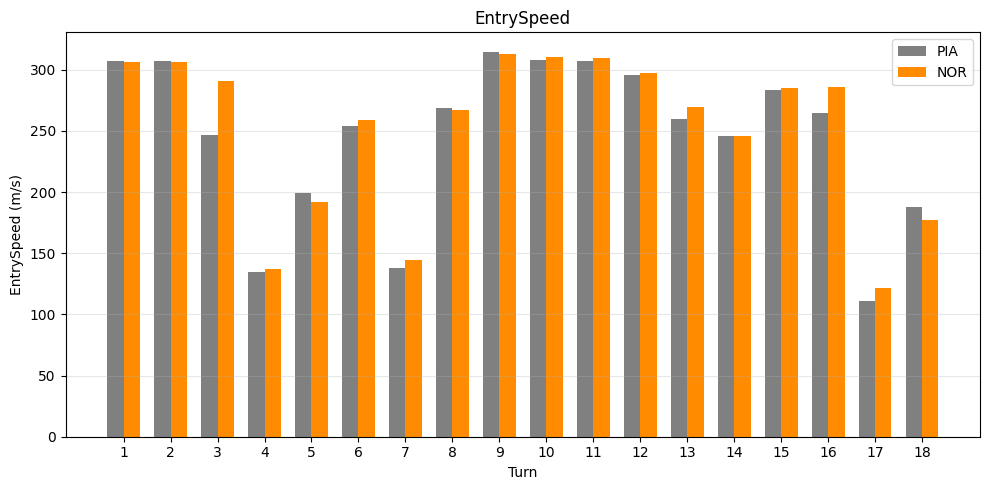

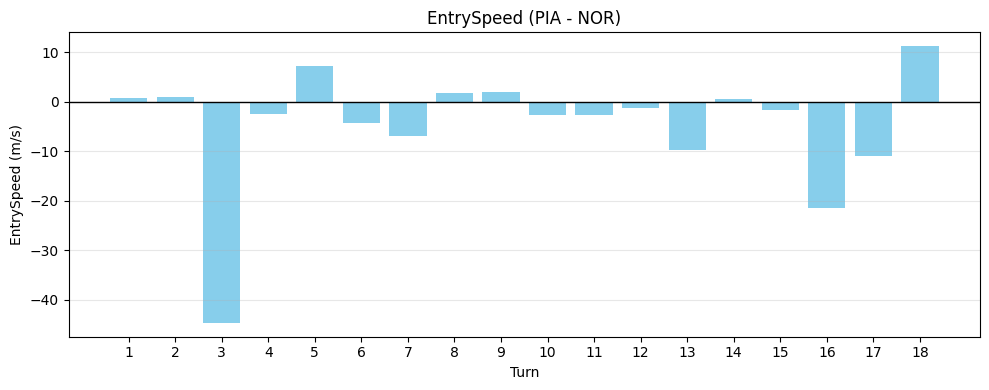

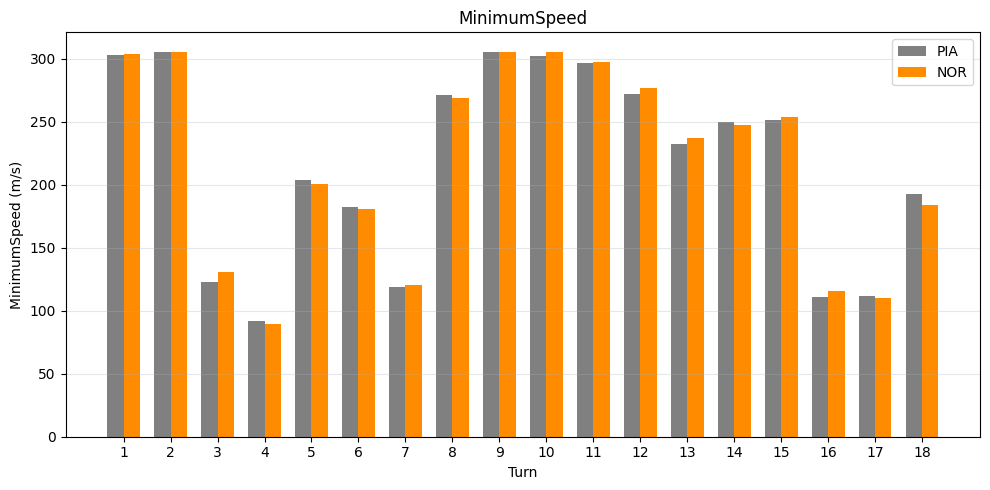

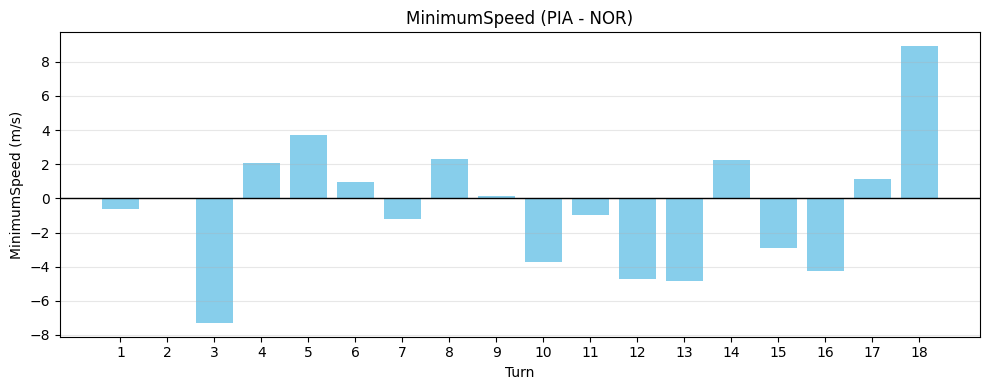

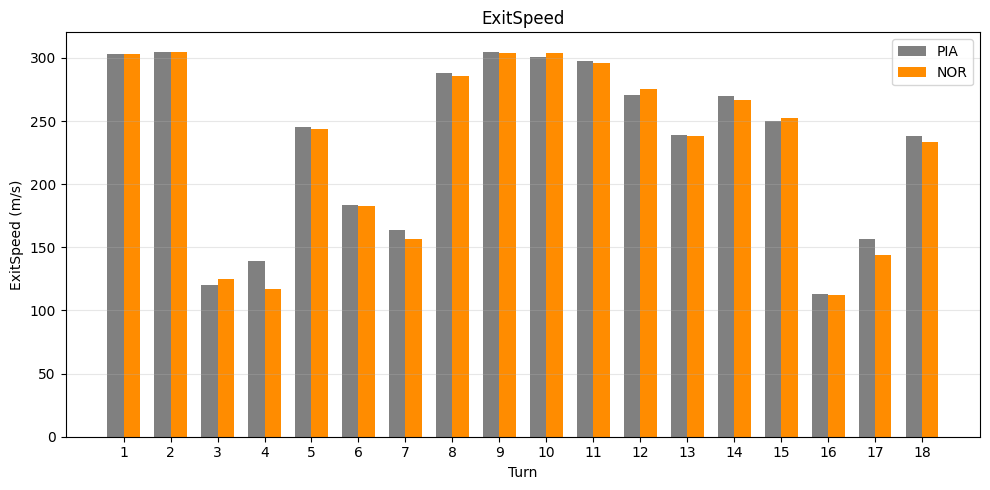

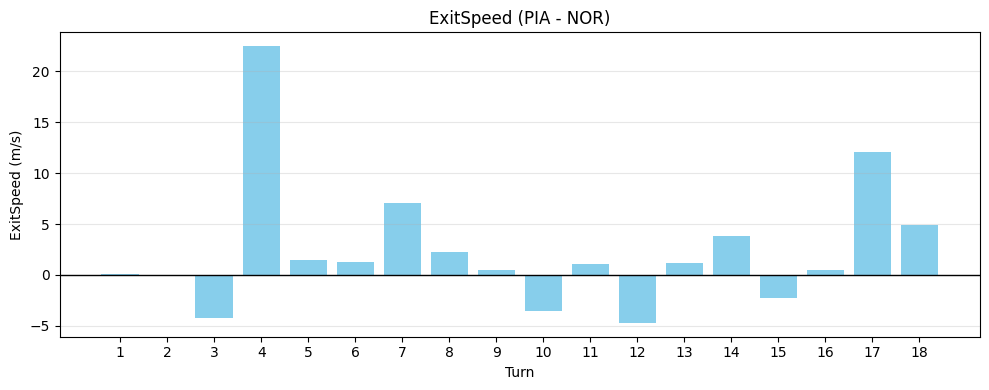

In [18]:
for feature in ["EntrySpeed", "MinimumSpeed", "ExitSpeed"]:
    fig = barplot_feature_comparison(lap_1, lap_2, "SpeedMetrics", feature, "m/s")
    save_figure(fig, "features", "comparison", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", feature, "m/s")
    save_figure(fig, "features", "delta", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)

## Braking Zone Analysis

Analyze differences in braking points and duration. This section helps identify which driver commits more aggressively to corner entry and how braking behavior impacts overall lap time.

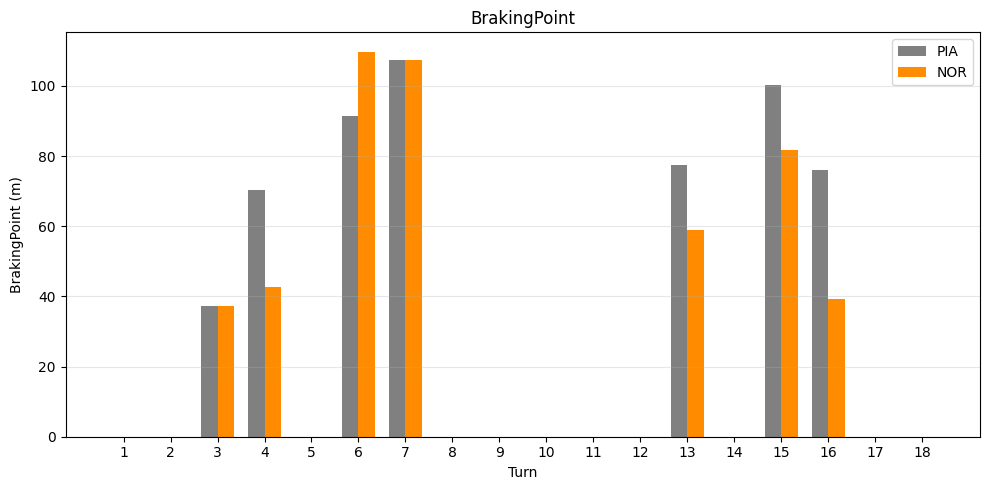

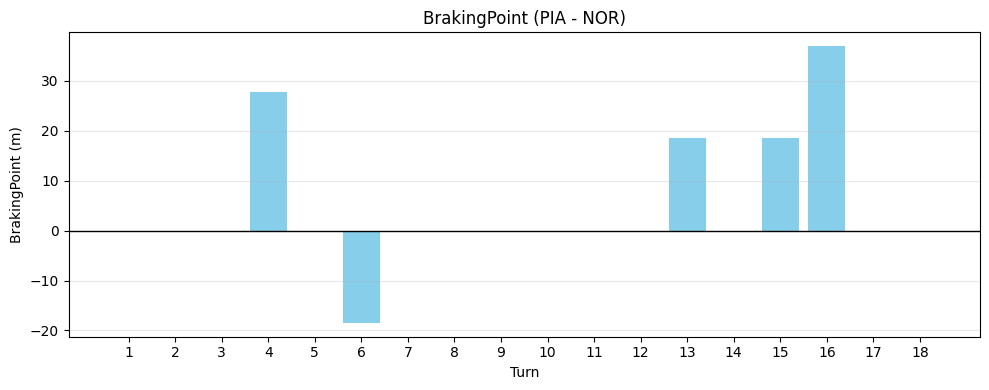

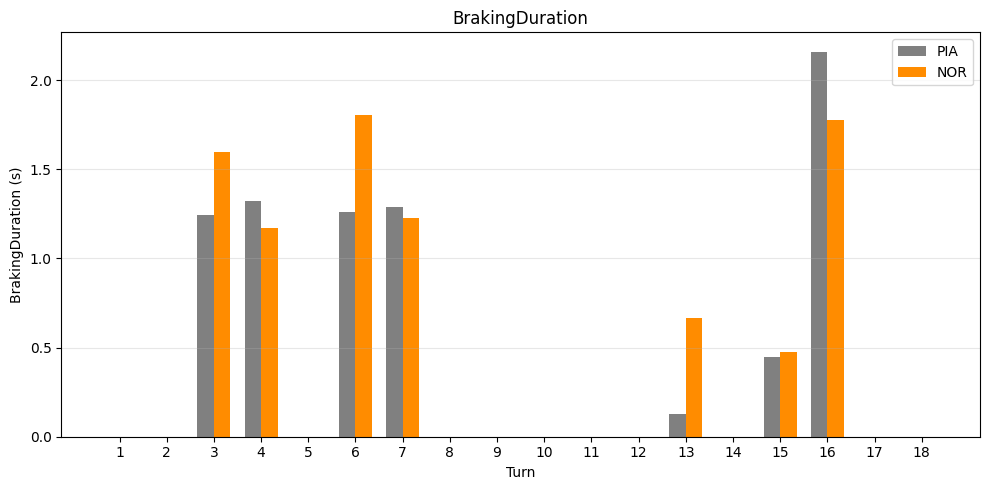

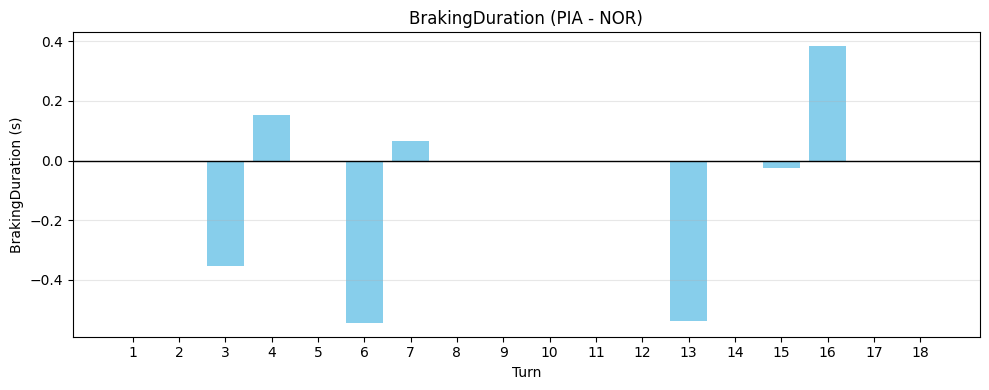

In [19]:
for feature in ["BrakingPoint", "BrakingDuration"]:
    fig = barplot_feature_comparison(lap_1, lap_2, "BrakingZones", feature, y_unit="m" if feature == "BrakingPoint" else "s")
    save_figure(fig, "features", "comparison", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, "BrakingZones", feature, y_unit="m" if feature == "BrakingPoint" else "s")
    save_figure(fig, "features", "delta", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)

## Throttle Segments Analysis

Compare mean and standard deviation of throttle usage, as well as the percentage of the segment spent at full throttle. These charts visualize traction management and power deployment differences upon corner exit.

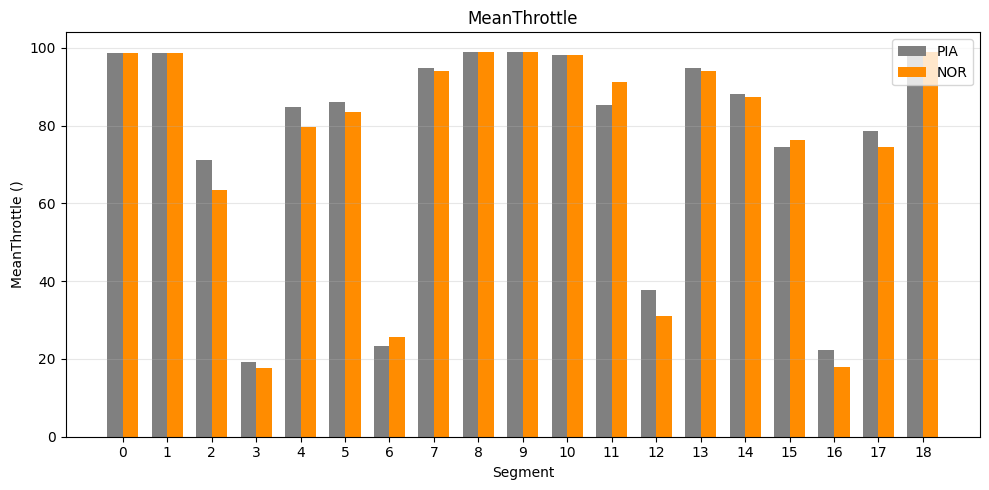

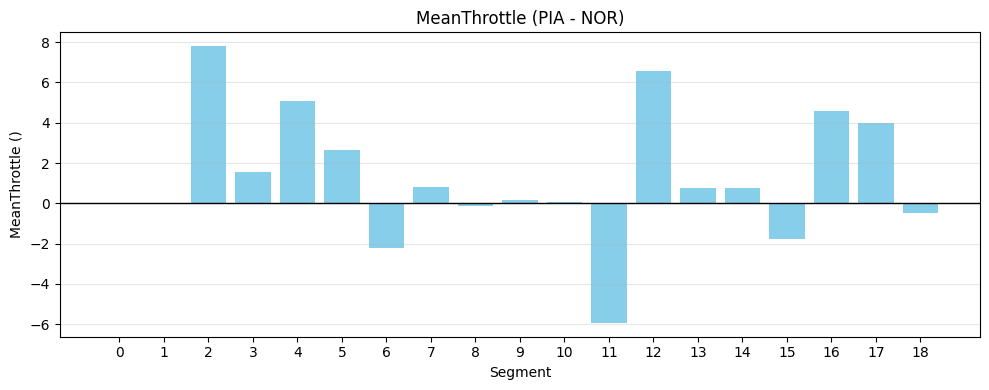

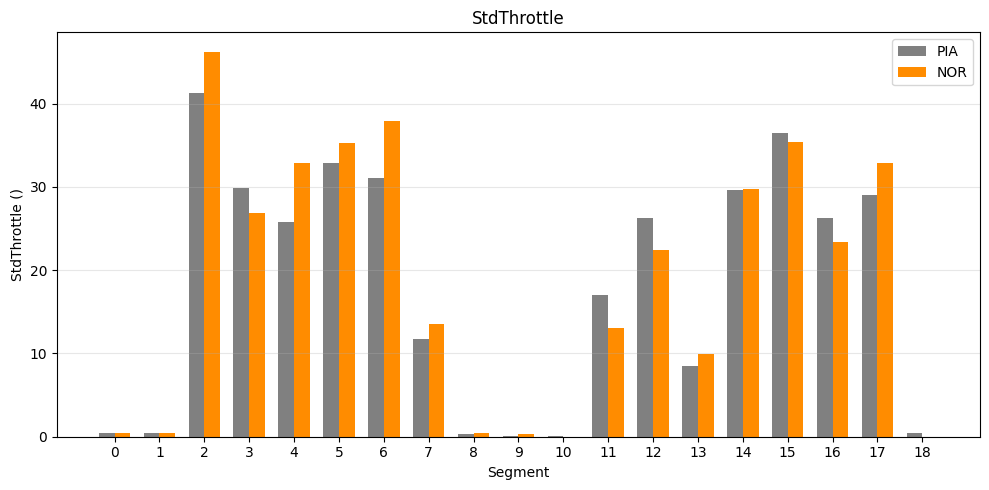

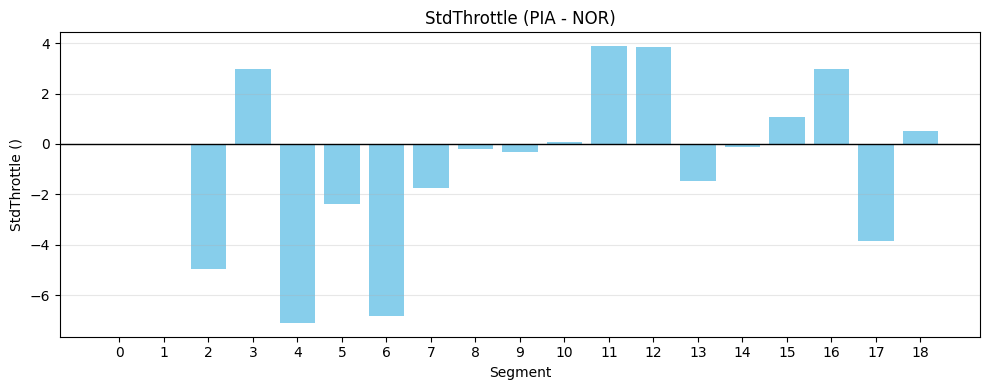

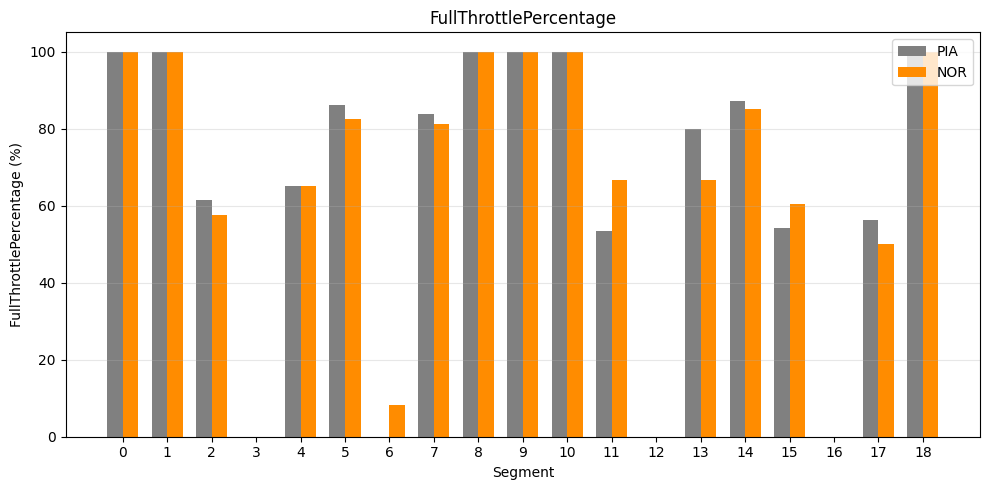

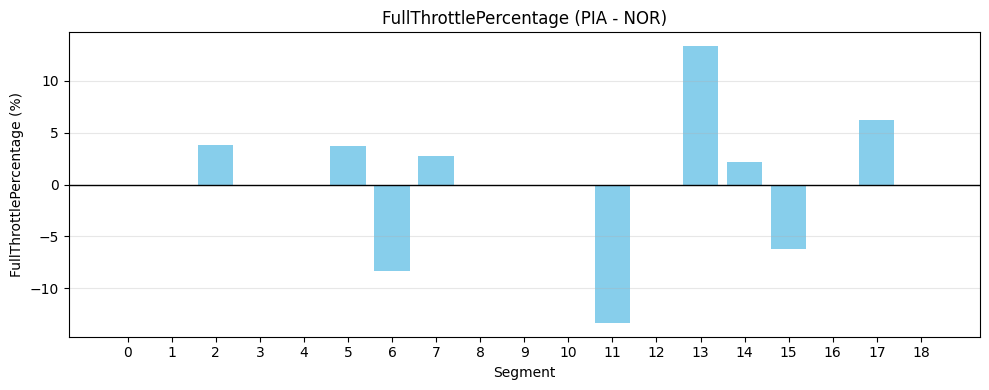

In [20]:
for feature, y_unit in [("MeanThrottle", ""), ("StdThrottle", ""), ("FullThrottlePercentage", "%")]:
    fig = barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", feature, y_unit=y_unit)
    save_figure(fig, "features", "comparison", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, "ThrottleSegments", feature, y_unit=y_unit)
    save_figure(fig, "features", "delta", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)

## Gear Shift Analysis

Examine transmission-related data, including the number of gear shifts, gear range (highest/lowest gear used), and engine RPM statistics. This identifies variations in gear selection strategies and how each driver manages power through different sections of the track.

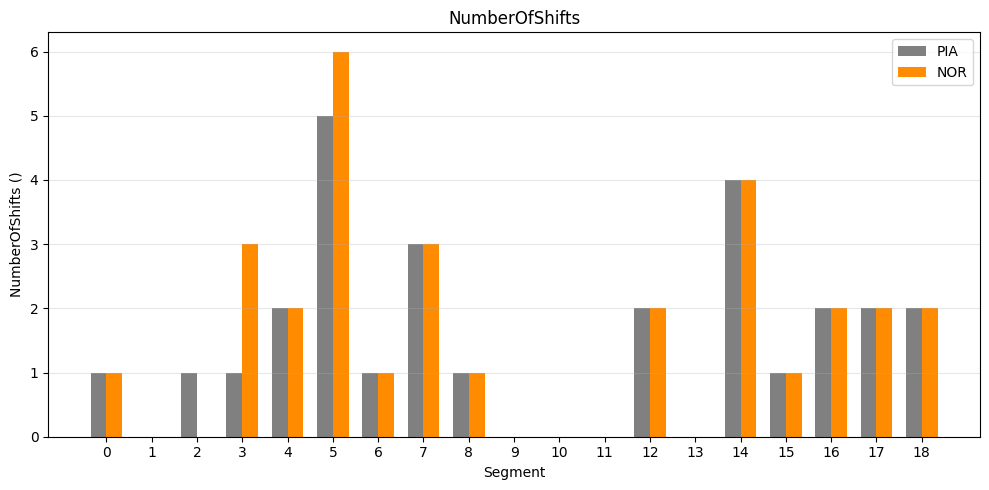

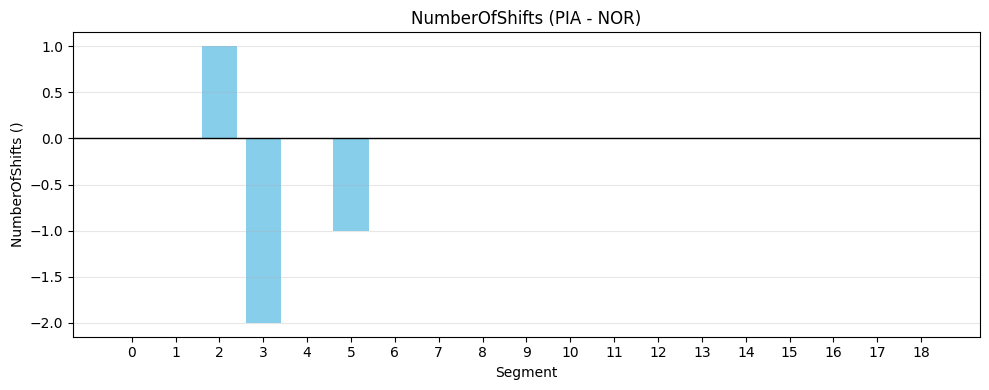

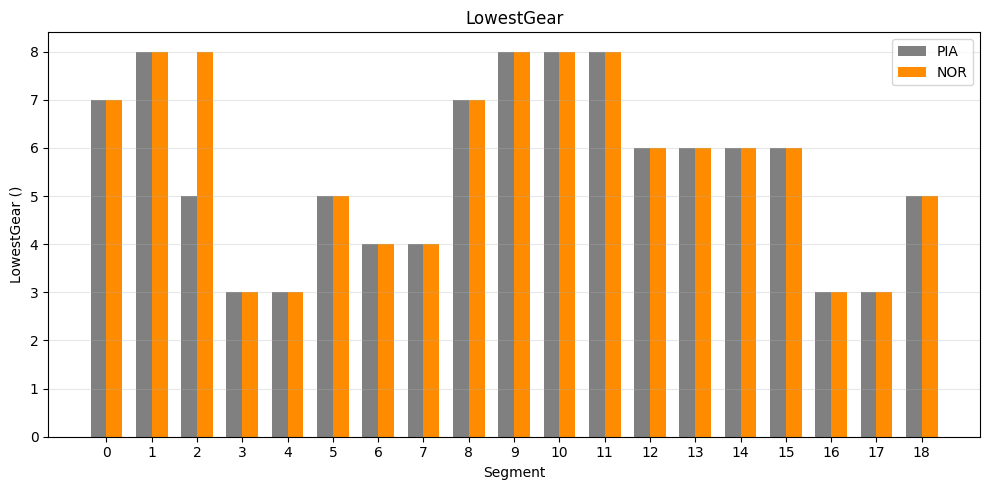

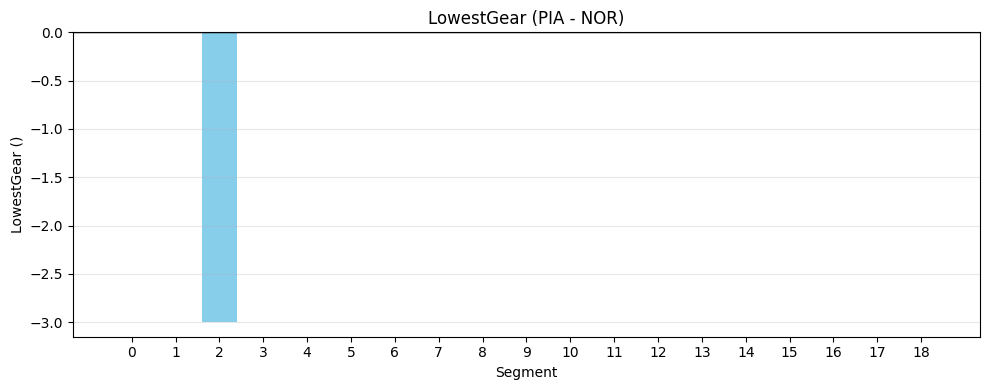

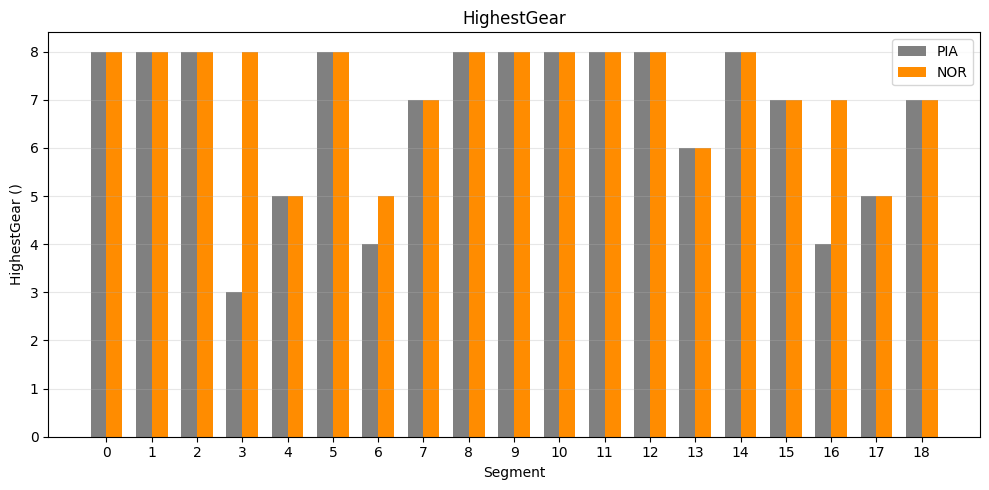

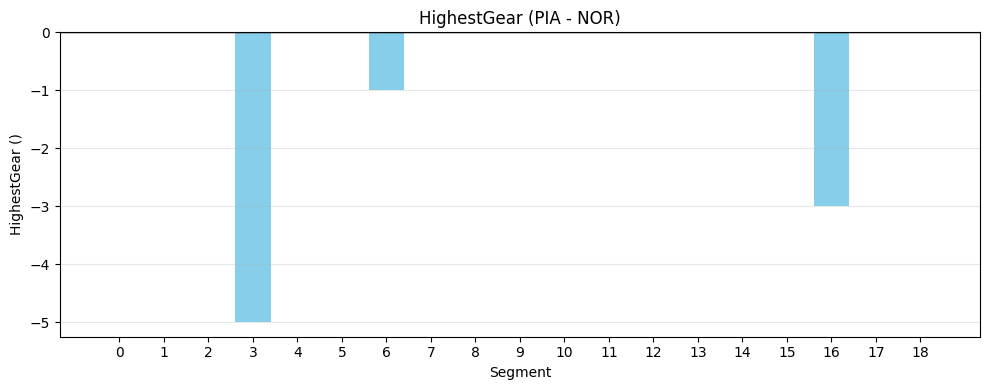

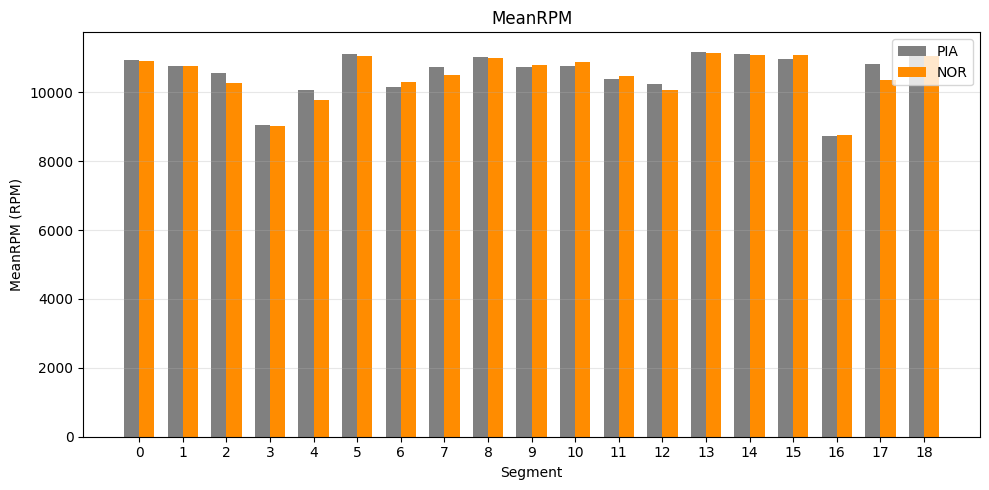

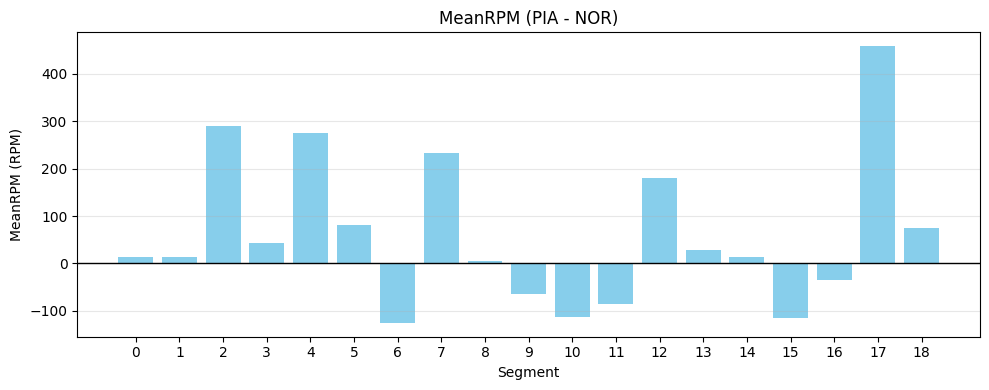

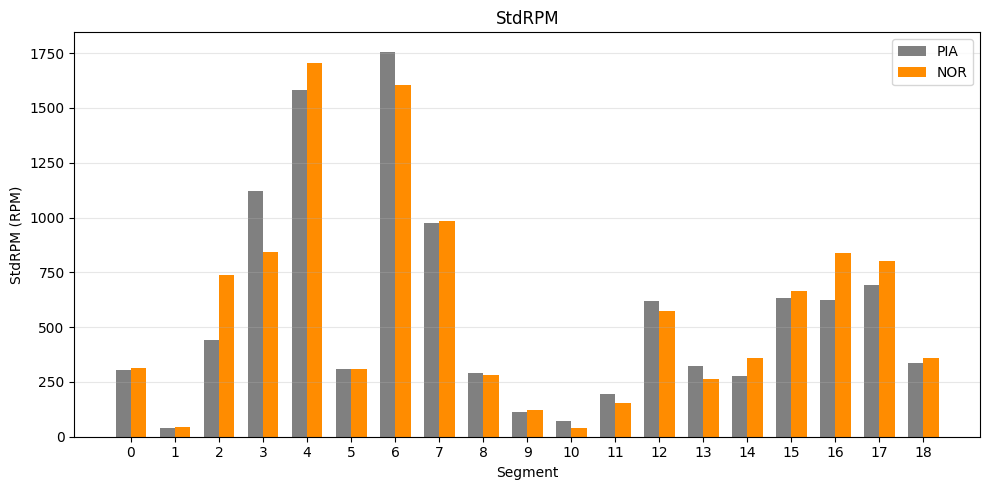

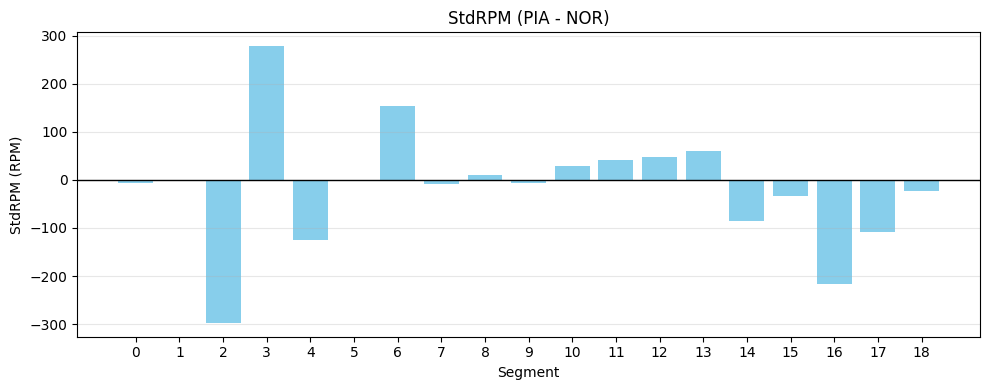

In [21]:
for feature, y_unit in [("NumberOfShifts", ""), ("LowestGear", ""), ("HighestGear", ""), ("MeanRPM", "RPM"), ("StdRPM", "RPM")]:
    fig = barplot_feature_comparison(lap_1, lap_2, "GearShifts", feature, y_unit=y_unit)
    save_figure(fig, "features", "comparison", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, "GearShifts", feature, y_unit=y_unit)
    save_figure(fig, "features", "delta", f"{feature.lower()}", year, grand_prix, team, driver_1, driver_2)

## Performance Correlations Analysis

Investigate relationships between different performance metrics (e.g., Entry Speed vs. Minimum Speed or Braking Point vs. Minimum Speed). Scatter plots here reveal how specific driving styles like early braking or throttle modulation correlate with exit speed and overall corner performance.

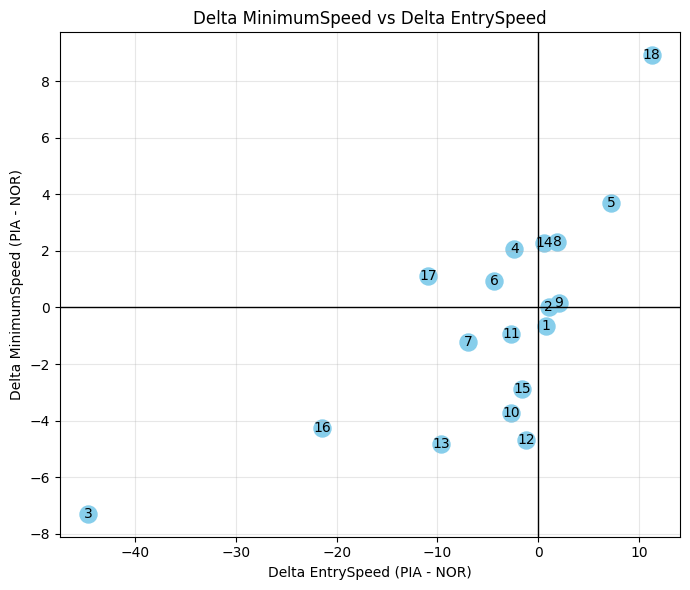

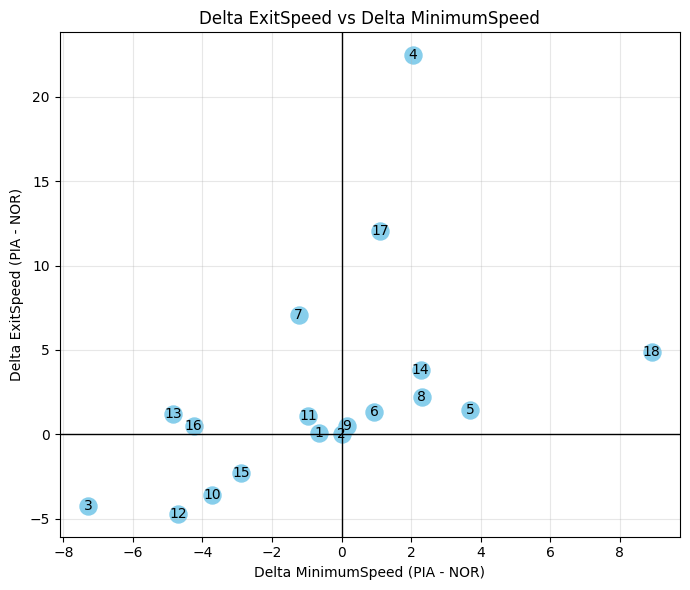

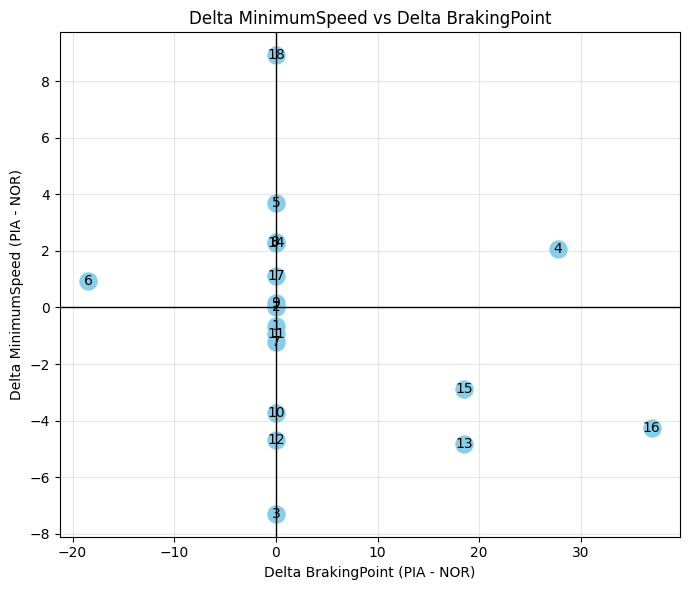

KeyError: "['Turn'] not in index"

In [22]:
for x_dataframe, x_feature, y_dataframe, y_feature in [
    ("SpeedMetrics","EntrySpeed","SpeedMetrics","MinimumSpeed"),
    ( "SpeedMetrics", "MinimumSpeed", "SpeedMetrics", "ExitSpeed"),
    ("BrakingZones","BrakingPoint","SpeedMetrics","MinimumSpeed"),
    ("ThrottleSegments","MeanThrottle","SpeedMetrics","ExitSpeed"),
]:
    fig = scatterplot_features_relationship(lap_1,lap_2, x_dataframe,x_feature,y_dataframe,y_feature)
    save_figure(fig, "features", "relationship", f"{x_feature.lower()}_{y_feature.lower()}", year, grand_prix, team, driver_1, driver_2)